In [1]:
!pip install -q -U transformers accelerate bitsandbytes 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 70.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 76.5 MB/s eta 0:00:00:00:01


In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("hugging face token") 

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [4]:
model_id = "google/gemma-4-e2b-it" 
tokenizer = AutoTokenizer.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [5]:
!pip install -q bitsandbytes

In [6]:
from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

In [7]:
summaries = [
    {
        "source": "doc1.pdf",
        "title": "Clinical Investigator Administrative Actions - Disqualification",
        "text": """This document outlines the enforcement process the FDA uses when a clinical investigator repeatedly or deliberately violates regulations or submits false information. It describes the steps (Notice of Initiation, opportunity to explain, consent agreement, hearing) that can lead to disqualification—meaning the investigator can no longer receive investigational products or conduct studies that support FDA applications. It follows GCP standards and regulations under 21 CFR Parts 312 and 812."""
    },
    {
        "source": "doc2.pdf",
        "title": "Clinical Considerations for IDEs for Neurological Devices",
        "text": """This guidance helps sponsors design clinical trials for neurological medical devices (e.g., for Alzheimer's, Parkinson's) that aim to slow or reverse disease. It emphasizes using biomarkers and clinical outcome assessments, discusses trial design challenges (distinguishing symptomatic vs. disease-altering effects), and stresses benefit-risk considerations, informed consent, and safety monitoring. It follows IDE regulations (21 CFR Part 812)."""
    },
    {
        "source": "doc3.pdf",
        "title": "E6(R3) Good Clinical Practice (GCP) Guidance",
        "text": """This is the comprehensive, international standard for designing, conducting, recording, and reporting clinical trials involving humans. It establishes 11 core principles (e.g., protect participant rights, informed consent, IRB oversight, quality by design, risk-proportionate approaches). It covers roles of IRBs, investigators, and sponsors, plus data governance, computerized systems, essential records, and the Investigator's Brochure. It follows ICH E6 GCP and aligns with the Declaration of Helsinki."""
    },
    {
        "source": "doc4.pdf",
        "title": "Conducting Clinical Trials With Decentralized Elements",
        "text": """This explains how to run trials where activities occur at locations other than traditional sites (e.g., patient's home, local labs, telehealth). It covers remote visits, use of digital health technologies (DHTs), direct shipment of investigational products, remote monitoring, and safety oversight. It emphasizes risk-based approaches and maintaining compliance with 21 CFR Parts 50, 56, 312, 812, and GCP."""
    },
    {
        "source": "doc5.pdf",
        "title": "Regulatory Submissions in Electronic Format Using eCTD",
        "text": """This is a binding requirement (not just a recommendation) that certain submissions (NDAs, ANDAs, BLAs, commercial INDs, master files) must be submitted electronically using the eCTD (Electronic Common Technical Document) format. It provides timetables, exemptions (e.g., noncommercial INDs, Type III DMFs), and waiver criteria. It follows Section 745A(a) of the FD&C Act."""
    },
    {
        "source": "doc6.pdf",
        "title": "E3 Structure and Content of Clinical Study Reports",
        "text": """This clarifies that the ICH E3 guidance on clinical study reports (CSRs) is not a rigid template but a flexible guide. It explains how to adapt the structure for different study types (e.g., pharmacokinetics, quality-of-life), how to handle appendices, and how to define important protocol deviations. It supports consistent, complete CSR reporting for regulatory submissions."""
    },
    {
        "source": "doc7.pdf",
        "title": "Electronic Source Data in Clinical Investigations",
        "text": """This promotes capturing source data electronically (e.g., from EHRs, devices, ePRO) directly into electronic case report forms (eCRFs). It defines data originators, audit trails, and the investigator's responsibility for reviewing and signing eCRFs. It addresses data integrity (ALCOA) and follows 21 CFR Part 11 (electronic records/signatures) and GCP."""
    },
    {
        "source": "doc8.pdf",
        "title": "Conduct of Clinical Trials during COVID-19",
        "text": """Issued during the pandemic, this guidance allows flexibility in trial conduct (e.g., remote visits, home delivery of investigational products, alternative safety monitoring) while prioritizing participant safety. It describes how to document protocol deviations due to COVID-19, submit amendments, and handle informed consent remotely. It follows GCP but with emergency adaptations under 21 CFR 312.30(b) and 812.35(a)."""
    },
    {
        "source": "doc9.pdf",
        "title": "Quality Systems Approach to Pharmaceutical CGMP",
        "text": """This aligns current Good Manufacturing Practices (CGMP) with modern quality systems (management responsibilities, resources, manufacturing operations, evaluation activities). It promotes quality by design, risk management, CAPA, and change control to ensure drug products consistently meet quality standards. It follows 21 CFR Parts 210 and 211 (CGMP for drugs)."""
    },
    {
        "source": "doc10.pdf",
        "title": "Process for Handling Referrals Under 21 CFR 50.54 - Children Safeguards",
        "text": """This describes the process when an IRB believes a clinical investigation involving children does not meet the usual pediatric research criteria (50.51–50.53). The IRB can refer it to FDA, which uses a Pediatric Ethics Subcommittee and public comment to determine if the study can proceed under 21 CFR 50.54 (reasonable opportunity to address a serious problem affecting children)."""
    },
    {
        "source": "doc11.pdf",
        "title": "ICH E8(R1) General Considerations for Clinical Studies",
        "text": """This provides the high-level framework for designing quality into clinical studies across the drug development lifecycle. It introduces critical to quality factors and a risk-based approach to study design, conduct, and reporting. It emphasizes patient input, scientific soundness, and flexibility. It serves as an umbrella guide to all ICH efficacy guidelines."""
    },
    {
        "source": "doc12.pdf",
        "title": "IRB Review of Stand-Alone HIPAA Authorizations",
        "text": """This clarifies that IRBs are not required by FDA to review and approve stand-alone HIPAA authorizations (documents that permit use of protected health information for research). It allows IRBs to modify their written procedures to exclude such reviews, preventing delays in trial enrollment. It addresses the intersection of 21 CFR Part 56 (IRB) and the HIPAA Privacy Rule."""
    },
    {
        "source": "doc13.pdf",
        "title": "Pre-Research Review, Recruitment, Enrollment, and Publication",
        "text": """This summarizes how the HIPAA Privacy Rule applies to pre-research record reviews, patient recruitment (e.g., physician can recruit own patients), enrollment (written HIPAA authorization), and publication (authorization needed if PHI included). It explains waivers of authorization and de-identification."""
    },
    {
        "source": "doc14.pdf",
        "title": "Leveraging Existing Clinical Data for Pediatric Uses of Medical Devices",
        "text": """This explains how adult clinical data can be extrapolated to support pediatric device indications (PMA, de novo, HDE) when the disease and device effects are similar. It introduces full vs. partial extrapolation and Bayesian statistical methods. Safety extrapolation is rarer than effectiveness extrapolation. It follows PMDSIA and 21 CFR 860.7 (valid scientific evidence)."""
    },
    {
        "source": "doc15.pdf",
        "title": "Questions and Answers on Informed Consent Elements 21 CFR 50.25(c)",
        "text": """This implements the FDAAA requirement that informed consent documents for applicable clinical trials must include a specific statement that a description of the trial will be available on ClinicalTrials.gov. It answers practical questions about timing (trials initiated on or after March 7, 2012), translation, and enforcement."""
    },
    {
        "source": "doc16.pdf",
        "title": "Use of Electronic Informed Consent eIC",
        "text": """This provides recommendations for using electronic systems and media (videos, hyperlinks, interactive interfaces) to obtain and document informed consent. It covers presentation, remote consent, identity verification, electronic signatures (21 CFR Part 11), pediatric considerations, and IRB responsibilities. It applies to both HHS (45 CFR 46) and FDA (21 CFR 50/56) regulations."""
    }
]

print(f"Ready: {len(summaries)} summaries")

Ready: 16 summaries


In [8]:
type(summaries)

list

In [9]:
import json
import re
from collections import defaultdict

def normalize(text: str) -> str:
    """Normalize concept names to lowercase with underscores."""
    return text.lower().replace(" ", "_").replace("-", "_").replace("(", "").replace(")", "").replace(",", "")

def extract_concepts_from_summary(title: str, text: str) -> dict:
    """Extract concepts and relationships, INCLUDING document-to-concept links."""
    
    concepts = []
    doc_name = normalize(title)
    found_concepts = []
    
    concept_mapping = {
        "disqualification": {"type": "enforcement_action", "related": ["investigator", "fda", "21_cfr_part_312", "21_cfr_part_812"]},
        "gcp": {"type": "standard", "related": ["clinical_trials", "ich", "declaration_of_helsinki"]},
        "ich_e6": {"type": "standard", "related": ["gcp", "clinical_trials"]},
        "informed_consent": {"type": "process", "related": ["irb", "subjects", "21_cfr_part_50"]},
        "irb": {"type": "oversight_body", "related": ["informed_consent", "human_subjects", "21_cfr_part_56"]},
        "decentralized_clinical_trials": {"type": "study_design", "related": ["telehealth", "dht", "remote_monitoring"]},
        "ectd": {"type": "submission_format", "related": ["nda", "anda", "bla", "ind"]},
        "electronic_source_data": {"type": "data_management", "related": ["ecrf", "audit_trail", "21_cfr_part_11"]},
        "cgmp": {"type": "manufacturing_standard", "related": ["quality_system", "21_cfr_part_210", "21_cfr_part_211"]},
        "pediatric_extrapolation": {"type": "regulatory_approach", "related": ["medical_devices", "bayesian_statistics"]},
        "hipaa": {"type": "privacy_law", "related": ["phi", "authorization", "irb"]},
        "clinical_study_report": {"type": "document", "related": ["ich_e3", "protocol_deviations"]},
    }
    
    for concept, info in concept_mapping.items():
        concept_keywords = [concept, concept.replace("_", " ")]
        if any(kw in text.lower() for kw in concept_keywords):
            found_concepts.append(concept)
            
            relationships = []
            for related in info["related"]:
                if related in text.lower():
                    relationships.append({"target": related, "type": "related_to"})
            
            concepts.append({
                "concept": concept,
                "type": info["type"],
                "relationships": relationships
            })
    
    # Add document-to-concept links (for traceability)
    doc_relationships = []
    for found in found_concepts:
        doc_relationships.append({"target": found, "type": "contains"})
        concepts.append({
            "concept": found,
            "type": concept_mapping.get(found, {}).get("type", "unknown"),
            "relationships": [{"target": doc_name, "type": "cited_in"}]
        })
    
    concepts.append({
        "concept": doc_name,
        "type": "guidance_document",
        "relationships": doc_relationships
    })
    
    return {"concepts": concepts}


# Process all summaries (assuming 'summaries' list exists from previous cell)
all_concepts = {}

for i, doc in enumerate(summaries):
    print(f"Processing {i+1}/16: {doc['title']}")
    
    result = extract_concepts_from_summary(doc["title"], doc["text"])
    
    for concept in result["concepts"]:
        key = concept["concept"]
        if key not in all_concepts:
            all_concepts[key] = concept
        else:
            existing_rels = {(r['target'], r['type']) for r in all_concepts[key].get('relationships', [])}
            for rel in concept.get('relationships', []):
                if (rel['target'], rel['type']) not in existing_rels:
                    all_concepts[key].setdefault('relationships', []).append(rel)

# Save to Kaggle working directory (visible in UI)
output_file = "/kaggle/working/final_knowledge_base.json"  
with open(output_file, "w") as f:
    json.dump(list(all_concepts.values()), f, indent=2)

print(f"\n✅ Done! Extracted {len(all_concepts)} unique concepts.")
print(f"Saved to {output_file}") 

Processing 1/16: Clinical Investigator Administrative Actions - Disqualification
Processing 2/16: Clinical Considerations for IDEs for Neurological Devices
Processing 3/16: E6(R3) Good Clinical Practice (GCP) Guidance
Processing 4/16: Conducting Clinical Trials With Decentralized Elements
Processing 5/16: Regulatory Submissions in Electronic Format Using eCTD
Processing 6/16: E3 Structure and Content of Clinical Study Reports
Processing 7/16: Electronic Source Data in Clinical Investigations
Processing 8/16: Conduct of Clinical Trials during COVID-19
Processing 9/16: Quality Systems Approach to Pharmaceutical CGMP
Processing 10/16: Process for Handling Referrals Under 21 CFR 50.54 - Children Safeguards
Processing 11/16: ICH E8(R1) General Considerations for Clinical Studies
Processing 12/16: IRB Review of Stand-Alone HIPAA Authorizations
Processing 13/16: Pre-Research Review, Recruitment, Enrollment, and Publication
Processing 14/16: Leveraging Existing Clinical Data for Pediatric Uses

In [10]:
# Install networkx if not already installed (Kaggle usually has it)
!pip install networkx matplotlib -q 
# Import all required libraries
import json
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np 
print("✅ Libraries loaded successfully")
print(f"NetworkX version: {nx.__version__}")

✅ Libraries loaded successfully
NetworkX version: 3.6.1


In [11]:
# Load the knowledge base you already created
with open("/kaggle/working/final_knowledge_base.json", "r") as f:
    knowledge_base = json.load(f) 
print(f"✅ Loaded {len(knowledge_base)} concepts")
print("\nFirst 5 concepts in your knowledge base:")
for i, concept in enumerate(knowledge_base[:5]):
    print(f"  {i+1}. {concept['concept']} ({concept['type']})") 

✅ Loaded 25 concepts

First 5 concepts in your knowledge base:
  1. disqualification (enforcement_action)
  2. gcp (standard)
  3. clinical_investigator_administrative_actions___disqualification (guidance_document)
  4. informed_consent (process)
  5. clinical_considerations_for_ides_for_neurological_devices (guidance_document)


In [12]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes and explicit relationships from your JSON
for concept in knowledge_base:
    # Add node with attributes
    G.add_node(concept['concept'], 
               type=concept['type'],
               node_type='concept')
    
    # Add edges from explicit relationships (if any exist)
    relationships = concept.get('relationships', [])
    if relationships:
        for rel in relationships:
            G.add_edge(concept['concept'], 
                       rel['target'], 
                       relationship=rel['type'],
                       inferred=False)
    else:
        # Optional: Print concepts with no relationships (for debugging)
        if concept['type'] != 'guidance_document':  # Skip documents
            print(f"⚠️ No relationships for: {concept['concept']} ({concept['type']})")

print(f"\n📊 Basic Graph Stats:")
print(f"   Nodes: {G.number_of_nodes()}")
print(f"   Edges: {G.number_of_edges()}")

# Show a sample of edges if any exist
edges_list = list(G.edges(data=True))
if edges_list:
    print(f"\n📋 Sample edges (first 5):")
    for i, (u, v, data) in enumerate(edges_list[:5]):
        print(f"   {i+1}. {u} → {data.get('relationship', 'unknown')} → {v}")
else:
    print(f"\n⚠️ No edges found! Your JSON has concepts but no relationships yet.")
    print(f"   This means we need to add relationships manually or with Gemma.")


📊 Basic Graph Stats:
   Nodes: 34
   Edges: 54

📋 Sample edges (first 5):
   1. disqualification → related_to → investigator
   2. disqualification → related_to → fda
   3. disqualification → cited_in → clinical_investigator_administrative_actions___disqualification
   4. clinical_investigator_administrative_actions___disqualification → contains → disqualification
   5. clinical_investigator_administrative_actions___disqualification → contains → gcp


/tmp/ipykernel_57/4250694686.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


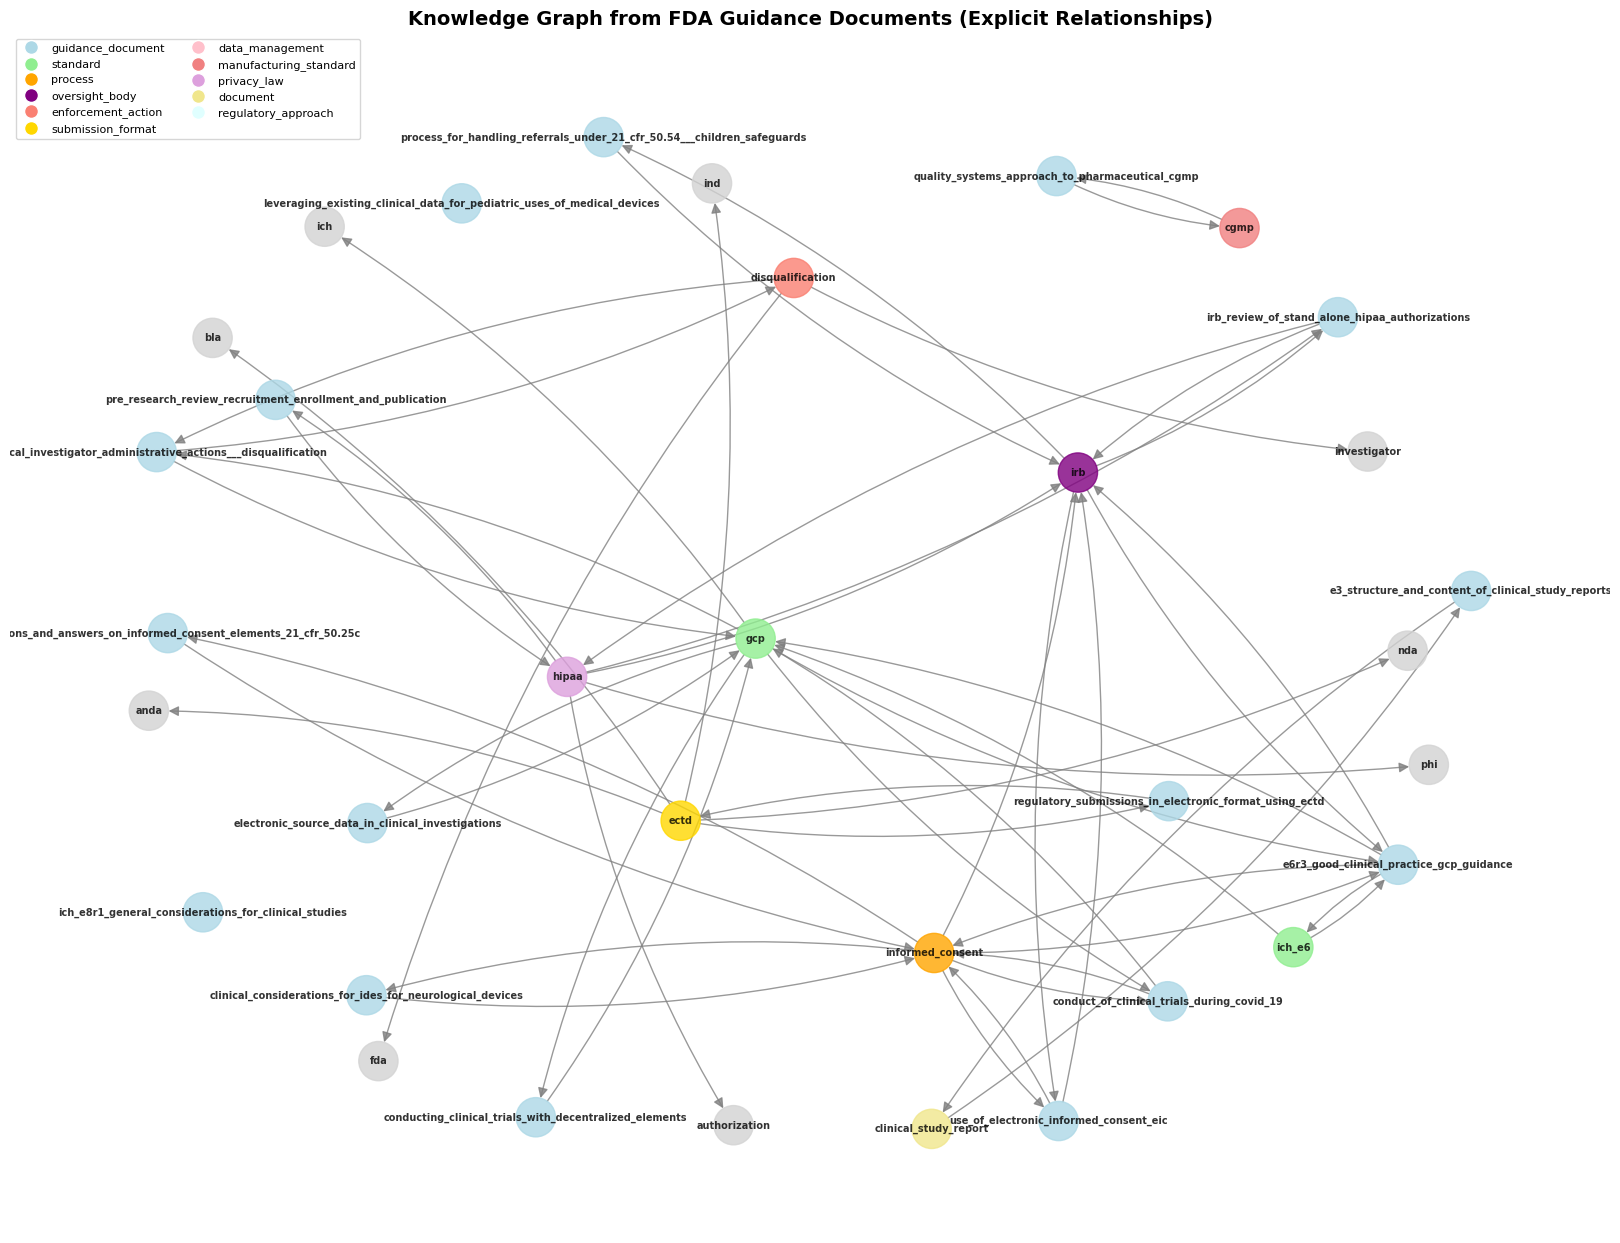

✅ Basic graph saved to /kaggle/working/knowledge_graph_basic.png


In [13]:
# Color mapping for different node types
color_map = {
    'guidance_document': 'lightblue',
    'standard': 'lightgreen', 
    'process': 'orange',
    'oversight_body': 'purple',
    'enforcement_action': 'salmon',
    'submission_format': 'gold',
    'data_management': 'pink',
    'manufacturing_standard': 'lightcoral',
    'privacy_law': 'plum',
    'document': 'khaki',
    'regulatory_approach': 'lightcyan'
}

# Assign colors to nodes
node_colors = []
for node in G.nodes():
    node_type = G.nodes[node].get('type', 'unknown')
    node_colors.append(color_map.get(node_type, 'lightgray'))

# Create visualization
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=1.5, seed=42, iterations=50)

nx.draw(G, pos, 
        node_color=node_colors,
        node_size=800,
        with_labels=True,
        font_size=7,
        font_weight='bold',
        edge_color='gray',
        arrows=True,
        arrowsize=15,
        alpha=0.8,
        connectionstyle='arc3,rad=0.1')

# Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=color, markersize=10, label=label)
                   for label, color in color_map.items()]

plt.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=2)
plt.title("Knowledge Graph from FDA Guidance Documents (Explicit Relationships)", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/knowledge_graph_basic.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Basic graph saved to /kaggle/working/knowledge_graph_basic.png")

/tmp/ipykernel_57/1735792401.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


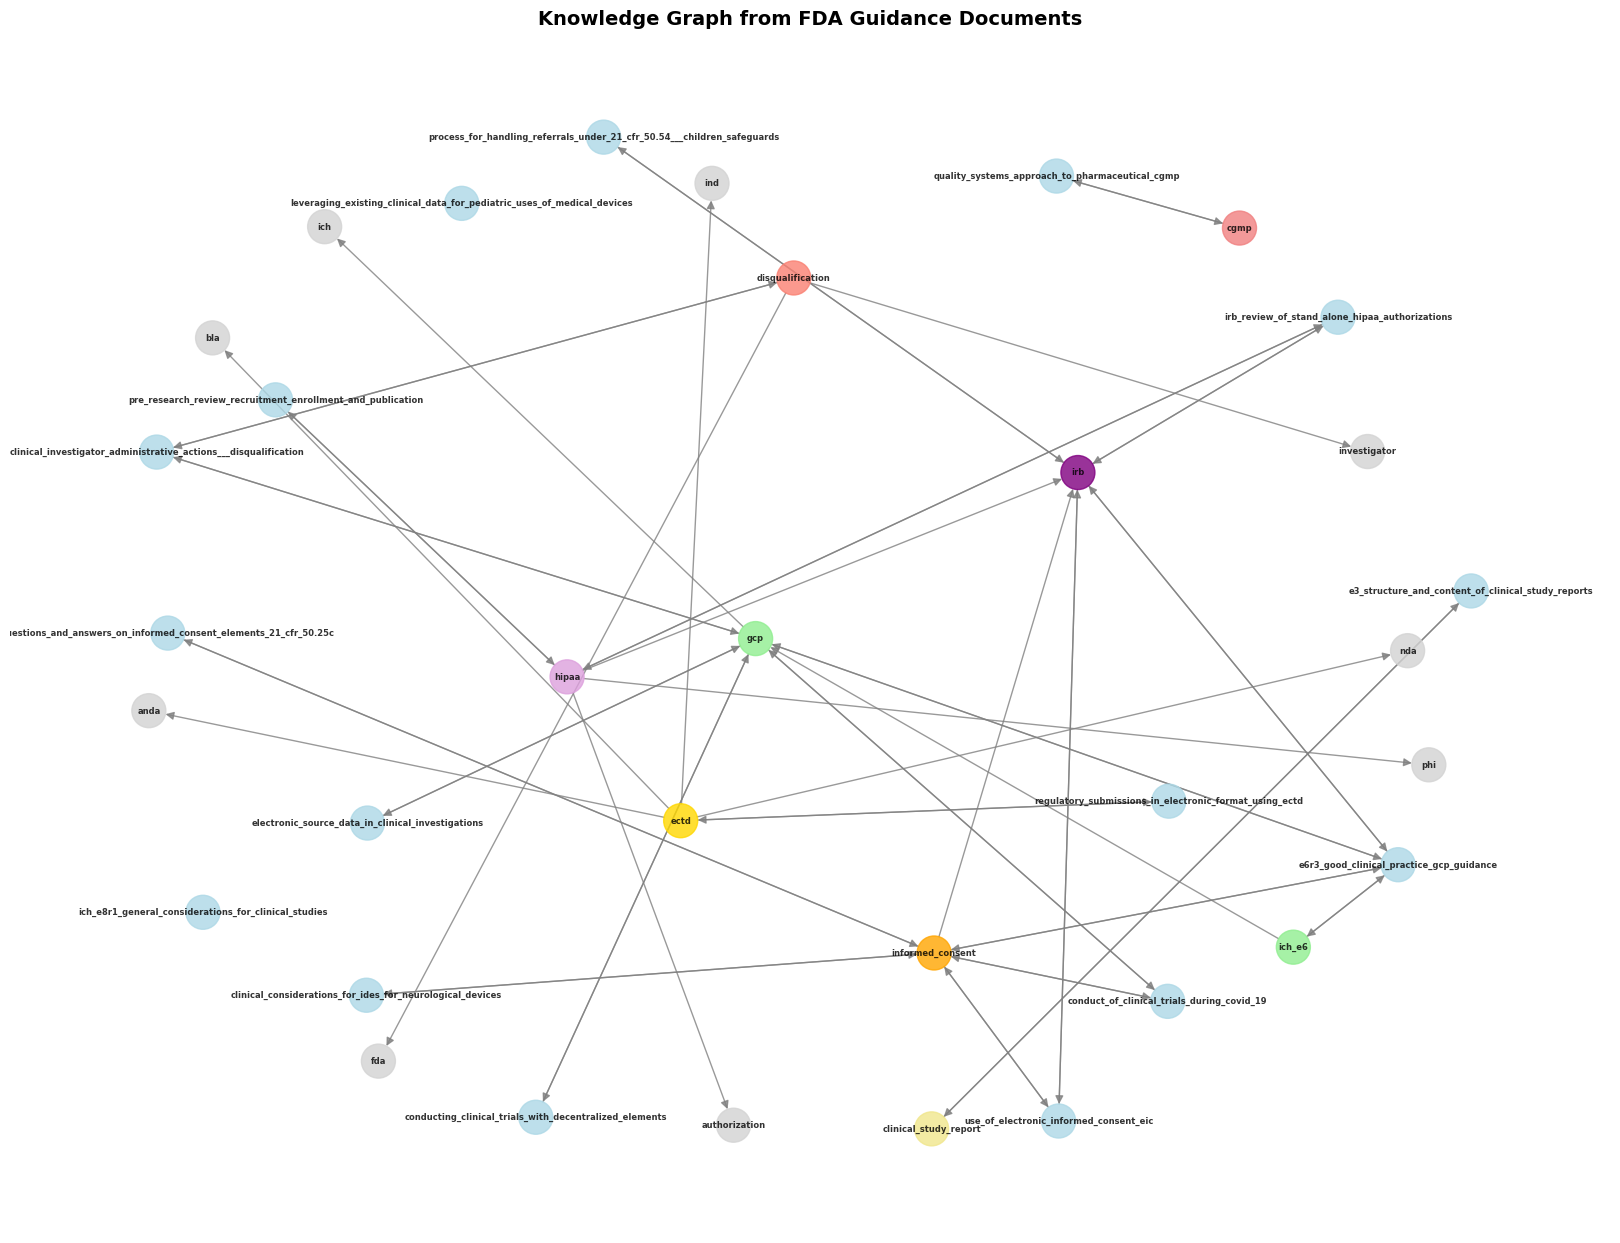

✅ Graph has 34 nodes and 54 edges
   Ready for explainability layer!


In [14]:
# Step 4: Visualize your working graph (you already have this code)
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=1.5, seed=42, iterations=50)

node_colors = [color_map.get(G.nodes[n].get('type', 'unknown'), 'lightgray') for n in G.nodes()]

nx.draw(G, pos, 
        node_color=node_colors,
        node_size=600,
        with_labels=True,
        font_size=6,
        font_weight='bold',
        edge_color='gray',
        arrows=True,
        arrowsize=12,
        alpha=0.8)

plt.title("Knowledge Graph from FDA Guidance Documents", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"   Ready for explainability layer!")

In [15]:

def ask_gemma(prompt):
    messages = [{"role": "user", "content": prompt}]
    
    # Step 1: format prompt correctly
    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True   # ✅ CRITICAL FIX
    )

    # Step 2: tokenize
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    # Step 3: generate
    outputs = model.generate(
        **inputs,
        max_new_tokens=700,   # increase a bit
        do_sample=True,
        temperature=0.2       # lower for structured output
    )

    # Step 4: remove input part
    input_length = inputs["input_ids"].shape[1]

    generated_tokens = outputs[0][input_length:]

    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return response.strip()

In [16]:
# Test relationship inference with your working ask_gemma
def infer_relationship_gemma(concept1, concept2):
    """Infer relationship between two concepts using Gemma."""
    
    prompt = f"""In FDA clinical trial regulations, what is the relationship between "{concept1}" and "{concept2}"?

Choose ONE word from: requires, part_of, governs, precedes, informs, related_to, same_as

Return ONLY the word, nothing else:
"""
    
    response = ask_gemma(prompt)
    response = response.strip().lower().replace('"', '').replace("'", "").split()[0]  # Take first word
    
    valid_rels = ['requires', 'part_of', 'governs', 'precedes', 'informs', 'related_to', 'same_as']
    if response in valid_rels:
        return response
    return 'related_to'

# Test on one pair
print("Testing relationship inference...")
rel = infer_relationship_gemma("gcp", "informed_consent")
print(f"Result: gcp → {rel} → informed_consent") 

Testing relationship inference...
Result: gcp → informs → informed_consent


In [17]:
meaningful_pairs = [
    ("gcp", "informed_consent"),
    ("irb", "informed_consent"),
    ("gcp", "ich_e6"),
    ("disqualification", "gcp"),
    ("hipaa", "irb"),
    ("ectd", "nda"),
    ("informed_consent", "hipaa"),
    ("irb", "disqualification"),
    ("cgmp", "quality_system"),
] 

# Check which pairs already have edges
existing_pairs = set()
for u, v, data in G.edges(data=True):
    existing_pairs.add((u, v))

# Filter to only new pairs
pairs_to_infer = [(c1, c2) for c1, c2 in meaningful_pairs 
                  if (c1, c2) not in existing_pairs and c1 in G and c2 in G]

print(f"📊 Pairs to infer: {len(pairs_to_infer)}")
for c1, c2 in pairs_to_infer:
    print(f"   - {c1} → ? → {c2}")

📊 Pairs to infer: 6
   - gcp → ? → informed_consent
   - irb → ? → informed_consent
   - gcp → ? → ich_e6
   - disqualification → ? → gcp
   - informed_consent → ? → hipaa
   - irb → ? → disqualification


In [18]:
print("🔄 Running Gemma relationship inference on meaningful pairs...\n")

inferred_relationships = []

for i, (c1, c2) in enumerate(pairs_to_infer):
    print(f"  [{i+1}/{len(pairs_to_infer)}] {c1} → ? → {c2}")
    
    rel_type = infer_relationship_gemma(c1, c2)
    print(f"      ✅ {c1} → {rel_type} → {c2}")
    
    inferred_relationships.append({
        'source': c1,
        'target': c2,
        'relationship': rel_type,
        'inferred': True
    })

print(f"\n✅ Inferred {len(inferred_relationships)} relationships")

🔄 Running Gemma relationship inference on meaningful pairs...

  [1/6] gcp → ? → informed_consent
      ✅ gcp → informs → informed_consent
  [2/6] irb → ? → informed_consent
      ✅ irb → related_to → informed_consent
  [3/6] gcp → ? → ich_e6
      ✅ gcp → related_to → ich_e6
  [4/6] disqualification → ? → gcp
      ✅ disqualification → governs → gcp
  [5/6] informed_consent → ? → hipaa
      ✅ informed_consent → related_to → hipaa
  [6/6] irb → ? → disqualification
      ✅ irb → related_to → disqualification

✅ Inferred 6 relationships


In [19]:
# Add inferred edges to the graph
for rel in inferred_relationships:
    G.add_edge(rel['source'], rel['target'], 
               relationship=rel['relationship'],
               inferred=True)

print(f"📊 Updated Graph Stats:")
print(f"   Nodes: {G.number_of_nodes()}")
print(f"   Edges: {G.number_of_edges()} (was 54, now +{len(inferred_relationships)})")

📊 Updated Graph Stats:
   Nodes: 34
   Edges: 60 (was 54, now +6)


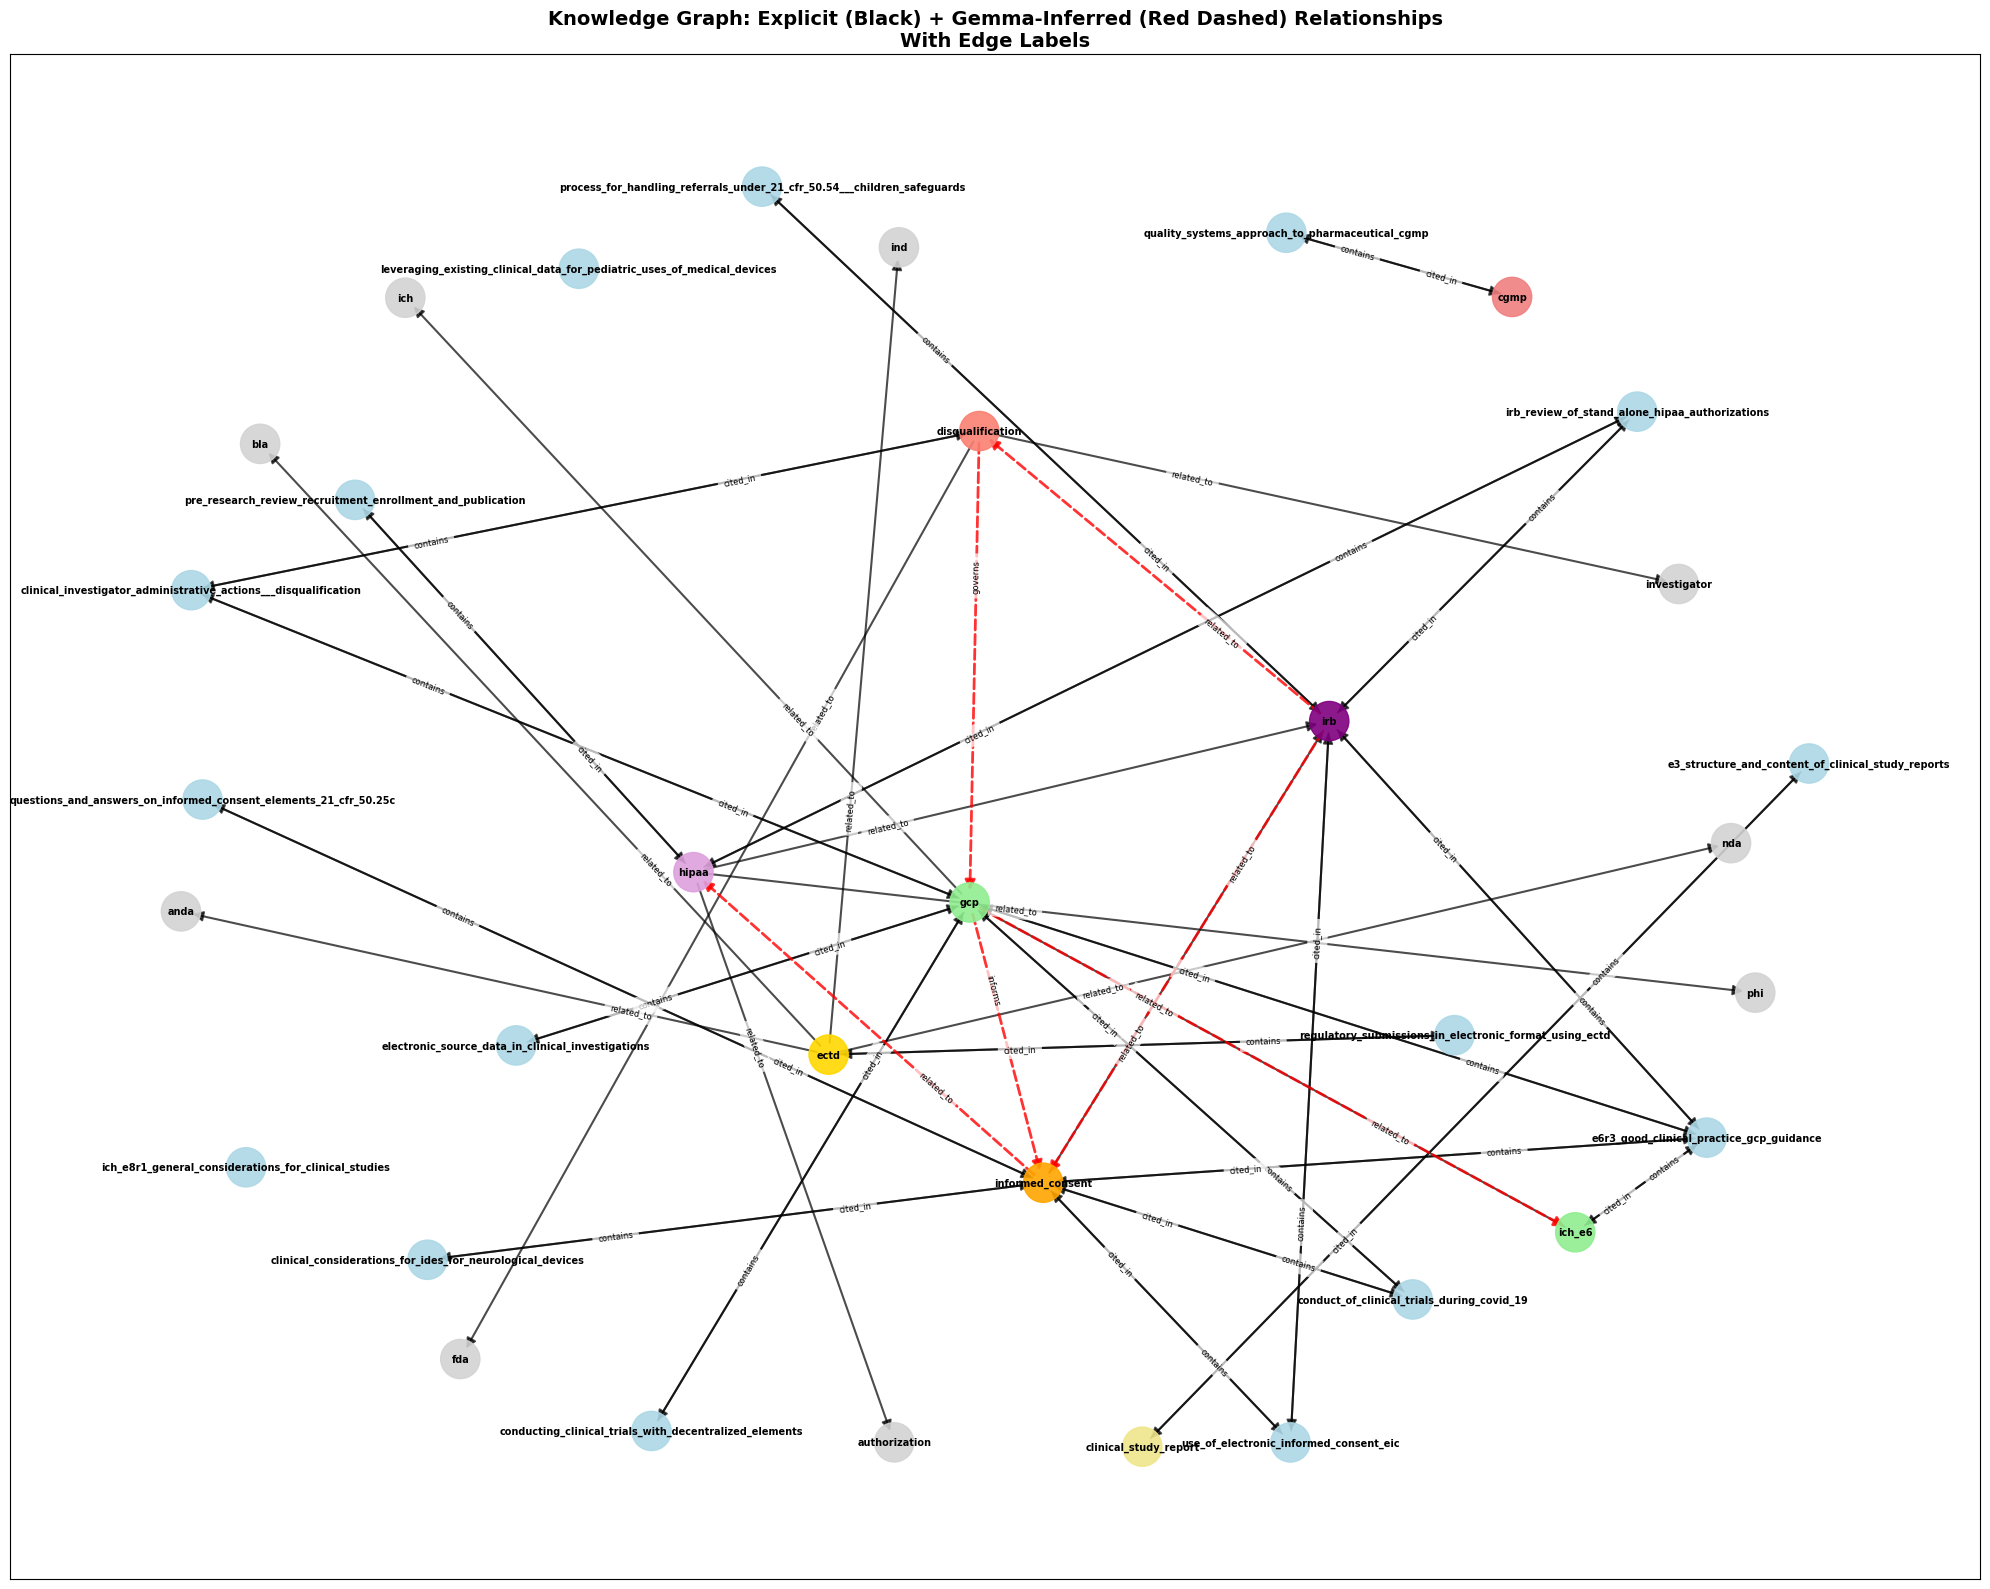

✅ Enhanced graph with edge labels saved to /kaggle/working/knowledge_graph_with_labels.png


In [20]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a fresh layout for consistency
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, k=1.5, seed=42, iterations=50)

# Draw nodes
node_colors = [color_map.get(G.nodes[n].get('type', 'unknown'), 'lightgray') for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, alpha=0.9)

# Draw explicit edges (black)
explicit_edges = [(u, v) for u, v, d in G.edges(data=True) if not d.get('inferred', False)]
nx.draw_networkx_edges(G, pos, edgelist=explicit_edges, edge_color='black', 
                       arrows=True, arrowsize=15, width=1.5, alpha=0.7)

# Draw inferred edges (red dashed)
inferred_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('inferred', False)]
nx.draw_networkx_edges(G, pos, edgelist=inferred_edges, edge_color='red', 
                       arrows=True, arrowsize=15, width=2, alpha=0.8, style='dashed')

# Draw labels for nodes
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')

# ✅ ADD EDGE LABELS
edge_labels = {(u, v): d['relationship'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                             font_size=6, label_pos=0.3, 
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.title("Knowledge Graph: Explicit (Black) + Gemma-Inferred (Red Dashed) Relationships\nWith Edge Labels", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/knowledge_graph_with_labels.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Enhanced graph with edge labels saved to /kaggle/working/knowledge_graph_with_labels.png")

In [21]:
import pandas as pd
import numpy as np

# Calculate various centrality metrics
print("\n" + "="*60)
print("📊 NODE CENTRALITY ANALYSIS")
print("="*60)

# Degree Centrality (number of connections)
degree_centrality = nx.degree_centrality(G)

# Betweenness Centrality (bridges between clusters)
betweenness_centrality = nx.betweenness_centrality(G)

# Closeness Centrality (how quickly a node can reach others)
closeness_centrality = nx.closeness_centrality(G)

# Eigenvector Centrality (connected to important nodes)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Create a DataFrame for easy viewing
centrality_df = pd.DataFrame({
    'node': list(G.nodes()),
    'type': [G.nodes[n].get('type', 'unknown') for n in G.nodes()],
    'degree_centrality': [degree_centrality[n] for n in G.nodes()],
    'betweenness_centrality': [betweenness_centrality[n] for n in G.nodes()],
    'closeness_centrality': [closeness_centrality[n] for n in G.nodes()],
    'eigenvector_centrality': [eigenvector_centrality[n] for n in G.nodes()]
})

# Sort by degree centrality (most connected first)
centrality_df = centrality_df.sort_values('degree_centrality', ascending=False)

print("\n🔗 TOP 10 MOST CONNECTED NODES (Degree Centrality):")
print("-" * 60)
for i, row in centrality_df.head(10).iterrows():
    print(f"   {row['node']} ({row['type']})")
    print(f"      Degree: {row['degree_centrality']:.3f} | Betweenness: {row['betweenness_centrality']:.3f}")

# Identify hub nodes (high degree, low betweenness = local hubs)
print("\n🌟 KEY HUB NODES (High connectivity, local importance):")
print("-" * 60)
hubs = centrality_df[(centrality_df['degree_centrality'] > 0.1) & 
                      (centrality_df['betweenness_centrality'] < 0.05)]
for i, row in hubs.head(5).iterrows():
    print(f"   • {row['node']} ({row['type']}) - {row['degree_centrality']:.2f} connections")

# Identify bridges (high betweenness = connect different parts of graph)
print("\n🌉 BRIDGE NODES (Connect different clusters):")
print("-" * 60)
bridges = centrality_df[centrality_df['betweenness_centrality'] > 0.05].sort_values('betweenness_centrality', ascending=False)
for i, row in bridges.head(5).iterrows():
    print(f"   • {row['node']} ({row['type']}) - Betweenness: {row['betweenness_centrality']:.3f}")


📊 NODE CENTRALITY ANALYSIS

🔗 TOP 10 MOST CONNECTED NODES (Degree Centrality):
------------------------------------------------------------
   gcp (standard)
      Degree: 0.455 | Betweenness: 0.118
   informed_consent (process)
      Degree: 0.424 | Betweenness: 0.131
   irb (oversight_body)
      Degree: 0.364 | Betweenness: 0.106
   e6r3_good_clinical_practice_gcp_guidance (guidance_document)
      Degree: 0.242 | Betweenness: 0.041
   hipaa (privacy_law)
      Degree: 0.242 | Betweenness: 0.065
   disqualification (enforcement_action)
      Degree: 0.182 | Betweenness: 0.047
   ectd (submission_format)
      Degree: 0.182 | Betweenness: 0.004
   irb_review_of_stand_alone_hipaa_authorizations (guidance_document)
      Degree: 0.121 | Betweenness: 0.004
   use_of_electronic_informed_consent_eic (guidance_document)
      Degree: 0.121 | Betweenness: 0.000
   ich_e6 (standard)
      Degree: 0.121 | Betweenness: 0.000

🌟 KEY HUB NODES (High connectivity, local importance):
------------

In [22]:
import pickle

# Save the complete graph with all nodes, edges, and centrality metrics
with open("/kaggle/working/knowledge_graph_complete.pkl", "wb") as f:
    pickle.dump(G, f)

print("✅ Knowledge graph saved to /kaggle/working/knowledge_graph_complete.pkl")
print(f"   Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Also save the centrality dataframe for reference
centrality_df.to_csv("/kaggle/working/centrality_analysis.csv", index=False)
print("✅ Centrality analysis saved to /kaggle/working/centrality_analysis.csv") 

✅ Knowledge graph saved to /kaggle/working/knowledge_graph_complete.pkl
   Graph has 34 nodes and 60 edges
✅ Centrality analysis saved to /kaggle/working/centrality_analysis.csv


In [23]:
with open("/kaggle/working/knowledge_graph_complete.pkl", "rb") as f:
    G = pickle.load(f)

print(f"✅ Loaded knowledge graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

✅ Loaded knowledge graph: 34 nodes, 60 edges


In [24]:
import pandas as pd

def extract_kg_context(knowledge_graph, top_n_concepts=15, centrality_csv_path="/kaggle/working/centrality_analysis.csv"):
    """Convert knowledge graph into readable context for Gemma, using pre-computed centrality."""
    
    # Load pre-computed centrality from CSV
    try:
        centrality_df = pd.read_csv(centrality_csv_path)
        # Create a dictionary for quick lookup: node -> degree_centrality
        centrality_dict = dict(zip(centrality_df['node'], centrality_df['degree_centrality']))
        print("Loaded centrality metrics from CSV")
    except FileNotFoundError:
        # Fallback: calculate if CSV not found
        print(" CSV not found, calculating centrality on the fly...")
        degree_centrality = nx.degree_centrality(knowledge_graph)
        centrality_dict = degree_centrality
    
    # Get concept nodes with their centrality scores
    concepts = []
    for node, data in knowledge_graph.nodes(data=True):
        if data.get('type') != 'guidance_document':
            concepts.append({
                'name': node,
                'type': data.get('type', 'unknown'),
                'centrality': centrality_dict.get(node, 0)
            })
    
    # Sort by centrality (highest first)
    concepts.sort(key=lambda x: -x['centrality'])
    
    # Get important relationships
    relationships = []
    for u, v, data in knowledge_graph.edges(data=True):
        if data.get('relationship') not in ['contains', 'cited_in']:
            relationships.append({
                'source': u,
                'target': v,
                'type': data.get('relationship', 'related_to')
            })
    
    # Build context string
    context = "KNOWLEDGE GRAPH (FDA Clinical Trial Regulations):\n\n"
    context += "IMPORTANT CONCEPTS (by importance, highest first):\n"
    for c in concepts[:top_n_concepts]:
        # Add priority label based on centrality
        if c['centrality'] >= 0.8:
            priority = "CRITICAL"
        elif c['centrality'] >= 0.4:
            priority = "HIGH"
        elif c['centrality'] >= 0.13:
            priority = "MEDIUM"
        else:
            priority = "LOW"
        context += f"  - {c['name']} ({c['type']}) - {priority} [score: {c['centrality']:.3f}]\n"
    
    context += "\nKEY RELATIONSHIPS:\n"
    for r in relationships[:30]:
        context += f"  - {r['source']} → {r['type']} → {r['target']}\n"
    
    return context

# Extract KG context (now uses your pre-computed CSV)
kg_context = extract_kg_context(G)
print("\n📚 Knowledge Graph Context (first 1000 chars):")
print(kg_context[:1000])

Loaded centrality metrics from CSV

📚 Knowledge Graph Context (first 1000 chars):
KNOWLEDGE GRAPH (FDA Clinical Trial Regulations):

IMPORTANT CONCEPTS (by importance, highest first):
  - gcp (standard) - HIGH [score: 0.455]
  - informed_consent (process) - HIGH [score: 0.424]
  - irb (oversight_body) - MEDIUM [score: 0.364]
  - hipaa (privacy_law) - MEDIUM [score: 0.242]
  - disqualification (enforcement_action) - MEDIUM [score: 0.182]
  - ectd (submission_format) - MEDIUM [score: 0.182]
  - ich_e6 (standard) - LOW [score: 0.121]
  - clinical_study_report (document) - LOW [score: 0.061]
  - cgmp (manufacturing_standard) - LOW [score: 0.061]
  - investigator (unknown) - LOW [score: 0.030]
  - fda (unknown) - LOW [score: 0.030]
  - ich (unknown) - LOW [score: 0.030]
  - nda (unknown) - LOW [score: 0.030]
  - anda (unknown) - LOW [score: 0.030]
  - bla (unknown) - LOW [score: 0.030]

KEY RELATIONSHIPS:
  - disqualification → related_to → investigator
  - disqualification → related_to → f

In [25]:
def gemma_compliance_analysis(document_text, kg_context, doc_type="SUBMISSION"):
    
    if doc_type == "SUBMISSION":
        one_shot_example = """
EXAMPLE OUTPUT (for a clinical trial protocol):

CONCEPTS_FOUND:
- gcp | Regulation: ICH E6(R3) Section 2.8 | Evidence: "study conducted per GCP guidelines" | KG: gcp → informs → informed_consent
- informed_consent | Regulation: 21 CFR 50.25 | Evidence: "written consent obtained from all subjects" | KG: informed_consent → required_by → irb

CONCEPTS_MISSING:
- hipaa | Regulation: 45 CFR 164.508 | Impact: Patient data has no privacy protection | Action: Add HIPAA authorization clause to consent section | KG Reason: informed_consent → related_to → hipaa
- protocol_deviations | Regulation: ICH E6(R3) Section 2.5.3 | Impact: No deviation handling plan risks data integrity | Action: Add deviation reporting section with timelines | KG Reason: gcp → requires → protocol_deviations

CRITICAL_GAP: hipaa — participant privacy unaddressed despite consent section existing

SUMMARY: Protocol covers GCP and consent but is missing HIPAA authorization and deviation management. Add both before IRB submission.
"""
        task_instruction = """Analyze this SUBMISSION DOCUMENT for compliance gaps.
Flag every required concept that is missing. These gaps could cause regulatory rejection.
Include the CRITICAL_GAP field for the single most important missing item."""

    else:
        one_shot_example = """
EXAMPLE OUTPUT (for ICH E6 GCP Guideline):

CONCEPTS_COVERED:
- gcp | Role: Core subject of this document | Section: Throughout | KG: gcp → informs → informed_consent
- informed_consent | Role: Defined and explained | Section: Section 2.8 | KG: informed_consent → required_by → irb
- protocol_deviations | Role: Addressed explicitly | Section: Section 2.5 | KG: gcp → requires → protocol_deviations

CONCEPTS_OUT_OF_SCOPE:
- hipaa | Reason: US-specific privacy law, separate regulatory domain | Note: Implementers should address separately
- cgmp | Reason: Manufacturing standard, outside GCP scope | Note: Covered by 21 CFR Part 211

ASSESSMENT: This document defines ICH GCP standards for clinical trial conduct. It is not a submission and is not expected to cover all regulatory domains. Coverage of core GCP concepts is comprehensive.

RECOMMENDATION: When using this guideline to design a clinical trial protocol, supplement with HIPAA authorization and local regulatory requirements.
"""
        task_instruction = """Analyze this GUIDANCE DOCUMENT to map what it covers and what is intentionally out of scope.
Do NOT flag missing concepts as gaps — this document defines standards, it does not submit to them.
Do NOT include a CRITICAL_GAP field. Use ASSESSMENT instead."""

    prompt = f"""You are an FDA clinical trial compliance expert. Analyze the document using the knowledge graph.

{kg_context}

Study this example of the EXACT output format required:

{one_shot_example}

NOW: {task_instruction}

DOCUMENT:
{document_text[:4000]}

Rules:
- Only reference concepts that appear in the knowledge graph
- Evidence/Section must be a direct quote or section number from the document
- KG fields must reference actual edges from the graph above
- SUMMARY or ASSESSMENT must be two sentences maximum
"""

    return ask_gemma(prompt) 


In [26]:
def detect_document_type(document_text):
    """Classify document before compliance analysis."""
    
    prompt = f"""Read the first part of this document and classify it.

DOCUMENT:
{document_text[:1500]}

Answer with EXACTLY one of these labels and one sentence of reasoning:

TYPE: SUBMISSION
REASON: [why it is a submission document]

OR

TYPE: GUIDANCE
REASON: [why it is a guidance/educational document]

Rules:
- SUBMISSION = clinical trial protocol, informed consent form, IRB application, IND/NDA/BLA document
- GUIDANCE = FDA guidance, ICH guideline, educational article, regulatory standard, policy document
"""
    response = ask_gemma(prompt)
    
    doc_type = "SUBMISSION"
    reason = ""
    
    for line in response.split("\n"):
        line = line.strip()
        if line.startswith("TYPE:"):
            raw = line.replace("TYPE:", "").strip().upper()
            if "GUIDANCE" in raw:
                doc_type = "GUIDANCE"
            else:
                doc_type = "SUBMISSION"
        elif line.startswith("REASON:"):
            reason = line.replace("REASON:", "").strip()
    
    return doc_type, reason 


In [27]:
def parse_compliance_output(gemma_response, doc_type="SUBMISSION"):
    
    if doc_type == "SUBMISSION":
        sections = {
            "concepts_found": [],
            "concepts_missing": [],
            "critical_gap": "",
            "summary": ""
        }
        section_map = {
            "CONCEPTS_FOUND:": "concepts_found",
            "CONCEPTS_MISSING:": "concepts_missing",
        }
        list_sections = ["concepts_found", "concepts_missing"]

    else:
        sections = {
            "concepts_covered": [],
            "concepts_out_of_scope": [],
            "assessment": "",
            "recommendation": ""
        }
        section_map = {
            "CONCEPTS_COVERED:": "concepts_covered",
            "CONCEPTS_OUT_OF_SCOPE:": "concepts_out_of_scope",
        }
        list_sections = ["concepts_covered", "concepts_out_of_scope"]

    current_section = None

    for line in gemma_response.split("\n"):
        line = line.strip()
        if not line:
            continue

        matched = False
        for header, key in section_map.items():
            if header in line:
                current_section = key
                matched = True
                break
        if matched:
            continue

        if "CRITICAL_GAP:" in line:
            sections["critical_gap"] = line.replace("CRITICAL_GAP:", "").strip()
            current_section = None
        elif "SUMMARY:" in line:
            sections["summary"] = line.replace("SUMMARY:", "").strip()
            current_section = None
        elif "ASSESSMENT:" in line:
            sections["assessment"] = line.replace("ASSESSMENT:", "").strip()
            current_section = None
        elif "RECOMMENDATION:" in line:
            sections["recommendation"] = line.replace("RECOMMENDATION:", "").strip()
            current_section = None
        elif line.startswith("-") and current_section in list_sections:
            raw = line[1:].strip()
            parts = [p.strip() for p in raw.split("|")]
            entry = {"name": parts[0] if parts else raw}
            for part in parts[1:]:
                if ":" in part:
                    k, v = part.split(":", 1)
                    entry[k.strip().lower().replace(" ", "_")] = v.strip()
            sections[current_section].append(entry)

    return sections


def format_final_report(parsed, doc_type, doc_type_reason,
                         sections_checked, total_sections):
    lines = []
    lines.append("=" * 70)
    lines.append("📋 COMPLIANCE ANALYSIS REPORT")
    lines.append("=" * 70)
    
    type_label = "Submission Document" if doc_type == "SUBMISSION" else "Guidance / Reference Document"
    lines.append(f"Document Type  : {type_label}")
    lines.append(f"Type Reasoning : {doc_type_reason}")
    lines.append(f"Sections Read  : {sections_checked}/{total_sections}\n")

    if doc_type == "SUBMISSION":
        lines.append("✅ REQUIREMENTS MET:")
        for c in parsed.get("concepts_found", []):
            lines.append(f"  • {c.get('name', '?')}")
            lines.append(f"    Regulation : {c.get('regulation', 'N/A')}")
            lines.append(f"    Evidence   : {c.get('evidence', 'N/A')}")
            if c.get('kg'):
                lines.append(f"    KG Link    : {c.get('kg')}")

        lines.append("\n❌ GAPS (would cause regulatory rejection):")
        for c in parsed.get("concepts_missing", []):
            lines.append(f"  • {c.get('name', '?')}")
            lines.append(f"    Regulation : {c.get('regulation', 'N/A')}")
            lines.append(f"    Risk       : {c.get('impact', 'N/A')}")
            lines.append(f"    Fix        : {c.get('action', 'N/A')}")
            if c.get('kg_reason'):
                lines.append(f"    KG Reason  : {c.get('kg_reason')}")

        if parsed.get("critical_gap"):
            lines.append(f"\n🔴 CRITICAL GAP : {parsed['critical_gap']}")
        if parsed.get("summary"):
            lines.append(f"\n📌 SUMMARY : {parsed['summary']}")

    else:
        lines.append("📚 CONCEPTS THIS DOCUMENT COVERS:")
        for c in parsed.get("concepts_covered", []):
            lines.append(f"  • {c.get('name', '?')}")
            lines.append(f"    Role       : {c.get('role', 'N/A')}")
            lines.append(f"    Section    : {c.get('section', 'N/A')}")
            if c.get('kg'):
                lines.append(f"    KG Link    : {c.get('kg')}")

        lines.append("\n⚪ OUT OF SCOPE (not expected in this document):")
        for c in parsed.get("concepts_out_of_scope", []):
            lines.append(f"  • {c.get('name', '?')}")
            lines.append(f"    Reason     : {c.get('reason', 'N/A')}")
            if c.get('note'):
                lines.append(f"    Note       : {c.get('note')}")

        if parsed.get("assessment"):
            lines.append(f"\n📋 ASSESSMENT : {parsed['assessment']}")
        if parsed.get("recommendation"):
            lines.append(f"\n💡 FOR IMPLEMENTERS : {parsed['recommendation']}")

    lines.append("=" * 70)
    return "\n".join(lines) 

In [28]:
def check_document_compliance(full_text, kg_context, section_size=3000):
    
    print("🔍 Detecting document type...")
    doc_type, doc_type_reason = detect_document_type(full_text)
    print(f"   → {doc_type}: {doc_type_reason}")

    words = full_text.split()
    sections = [
        " ".join(words[i:i+section_size])
        for i in range(0, len(words), section_size)
    ]
    print(f"   → {len(sections)} sections total, checking first 3...")

    if doc_type == "SUBMISSION":
        all_found, all_missing = [], []
    else:
        all_covered, all_oos = [], []

    final_parsed = None

    for i, section in enumerate(sections[:3]):
        print(f"   Checking section {i+1}/3...")
        raw = gemma_compliance_analysis(section, kg_context, doc_type)
        parsed = parse_compliance_output(raw, doc_type)

        if doc_type == "SUBMISSION":
            all_found.extend(parsed.get("concepts_found", []))
            all_missing.extend(parsed.get("concepts_missing", []))
        else:
            all_covered.extend(parsed.get("concepts_covered", []))
            all_oos.extend(parsed.get("concepts_out_of_scope", []))

        final_parsed = parsed

    def dedup(lst):
        seen, out = set(), []
        for item in lst:
            name = item.get("name", "").lower()
            if name not in seen:
                seen.add(name)
                out.append(item)
        return out

    if doc_type == "SUBMISSION":
        found_names = {c.get("name","").lower() for c in dedup(all_found)}
        final_parsed["concepts_found"] = dedup(all_found)
        final_parsed["concepts_missing"] = [
            c for c in dedup(all_missing)
            if c.get("name","").lower() not in found_names
        ]
    else:
        final_parsed["concepts_covered"] = dedup(all_covered)
        final_parsed["concepts_out_of_scope"] = dedup(all_oos)

    return final_parsed, doc_type, doc_type_reason, min(3, len(sections)), len(sections) 


In [29]:
!pip install PyMuPDF 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 73.2 MB/s eta 0:00:00:00:0100:01


In [30]:
import fitz

def extract_text_from_pdf(pdf_path):
    """Extract text from PDF file."""
    doc = fitz.open(pdf_path)
    full_text = ""
    for page in doc:
        full_text += page.get_text()
    doc.close()
    return full_text

pdf_path = "/kaggle/input/datasets/sanjanakatala/documents/testing_docs/test-doc-7.pdf"
test_text = extract_text_from_pdf(pdf_path) 

In [31]:
final_parsed, doc_type, doc_type_reason, checked, total = check_document_compliance(
    test_text, kg_context
)

report = format_final_report(
    final_parsed, doc_type, doc_type_reason, checked, total
)
print(report)

🔍 Detecting document type...
   → GUIDANCE: This document is an educational article summarizing key aspects of the Privacy Rule's compliance for readers familiar with the basic concepts, which fits the definition of an educational article.
   → 1 sections total, checking first 3...
   Checking section 1/3...
📋 COMPLIANCE ANALYSIS REPORT
Document Type  : Guidance / Reference Document
Type Reasoning : This document is an educational article summarizing key aspects of the Privacy Rule's compliance for readers familiar with the basic concepts, which fits the definition of an educational article.
Sections Read  : 1/1

📚 CONCEPTS THIS DOCUMENT COVERS:
  • hipaa
    Role       : Discussed as the governing law for privacy in clinical trials
    Section    : Throughout
    KG Link    : hipaa → related_to → authorization
  • informed_consent
    Role       : Required for enrollment, even if not a HIPAA requirement
    Section    : 2.2 (Recruitment)
    KG Link    : informed_consent → related_to 

In [32]:
!pip install fastapi uvicorn python-multipart pyngrok nest-asyncio -q

print("✅ Packages installed") 

✅ Packages installed


In [33]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import threading
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
import fitz

# Apply nest_asyncio for running in notebook
nest_asyncio.apply()

# Create FastAPI app
app = FastAPI(title="FDA Compliance Checker API")

# Enable CORS for Lovable/Vercel frontend
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.post("/analyze")
async def analyze(file: UploadFile = File(...)):
    """Analyze uploaded PDF and return compliance report"""
    try:
        # Read and extract text from PDF
        contents = await file.read()
        doc = fitz.open(stream=contents, filetype="pdf")
        full_text = ""
        for page in doc:
            full_text += page.get_text()
        doc.close()
        
        if not full_text.strip():
            return JSONResponse(
                status_code=400,
                content={"success": False, "error": "Could not extract text from PDF. File may be scanned or empty."}
            )
        
        # Run compliance check (using your existing functions)
        final_parsed, doc_type, doc_type_reason, checked, total = check_document_compliance(
            full_text, kg_context
        )
        
        # Generate formatted report
        formatted_report = format_final_report(
            final_parsed, doc_type, doc_type_reason, checked, total
        )
        
        # Return as JSON for frontend
        return {
            "success": True,
            "doc_type": doc_type,
            "doc_type_reason": doc_type_reason,
            "sections_checked": checked,
            "total_sections": total,
            "concepts_found": final_parsed.get("concepts_found", []) if doc_type == "SUBMISSION" else final_parsed.get("concepts_covered", []),
            "concepts_missing_out_of_scope": final_parsed.get("concepts_missing", []) if doc_type == "SUBMISSION" else final_parsed.get("concepts_out_of_scope", []),
            "assessment": final_parsed.get("assessment", ""),
            "recommendation": final_parsed.get("recommendation", ""),
            # "critical_gap": final_parsed.get("critical_gap", ""),
            "formatted_report": formatted_report
        }
    
    except Exception as e:
        return JSONResponse(
            status_code=500,
            content={"success": False, "error": str(e)}
        )

@app.get("/health")
def health():
    return {"status": "running", "message": "FDA Compliance Checker API is live"}

print("✅ FastAPI app created")

✅ FastAPI app created


In [34]:
# Set your authtoken (replace with your actual token)
ngrok.set_auth_token("2dG1oMd8FcPzAQqK0TH2T5XhK3S_2RadRUShoPxmFXhLBv6VW")  # Paste your token inside the quotes

print("✅ Auth token set")

✅ Auth token set                                                                                    


In [36]:
# Kill any existing
ngrok.kill()

# Create tunnel
public_url = ngrok.connect(8000)

print("=" * 60)
print("🚀 FDA COMPLIANCE CHECKER API IS LIVE!")
print("=" * 60)
# print(f"\n📡 SHARE THIS URL WITH YOUR COUSIN:")
print(f"   {public_url}")
print(f"\n🔗 Endpoints:")
print(f"   POST {public_url}/analyze  (Upload PDF)")
print(f"   GET  {public_url}/health   (Check status)")
print("=" * 60)

🚀 FDA COMPLIANCE CHECKER API IS LIVE!
   NgrokTunnel: "https://8fa9-34-42-59-101.ngrok-free.app" -> "http://localhost:8000"

🔗 Endpoints:
   POST NgrokTunnel: "https://8fa9-34-42-59-101.ngrok-free.app" -> "http://localhost:8000"/analyze  (Upload PDF)
   GET  NgrokTunnel: "https://8fa9-34-42-59-101.ngrok-free.app" -> "http://localhost:8000"/health   (Check status)
